# Mini Project: Dry Bean Type Classification



## Task 1: Import and Load the Data

In [3]:
# ─── Core Libraries ───
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─── Visualization ───
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

# ─── Preprocessing & Splitting ───
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ─── Classification Models ───
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from scipy import stats



In [4]:
# Load the dataset
df = pd.read_excel('Dry_Bean_Dataset.xlsx')
print(f'Dataset loaded  —  {df.shape[0]} rows  ×  {df.shape[1]} columns')

Dataset loaded  —  13611 rows  ×  17 columns


In [5]:
# Quick peek at the first few records
df.head(10)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
5,30279,634.927,212.560556,181.510182,1.171067,0.520401,30600,196.347702,0.775688,0.989510,0.943852,0.923726,0.007020,0.003153,0.853270,0.999236,SEKER
6,30477,670.033,211.050155,184.039050,1.146768,0.489478,30970,196.988633,0.762402,0.984081,0.853080,0.933374,0.006925,0.003242,0.871186,0.999049,SEKER
7,30519,629.727,212.996755,182.737204,1.165591,0.513760,30847,197.124320,0.770682,0.989367,0.967109,0.925480,0.006979,0.003158,0.856514,0.998345,SEKER
8,30685,635.681,213.534145,183.157146,1.165852,0.514081,31044,197.659696,0.771561,0.988436,0.954240,0.925658,0.006959,0.003152,0.856844,0.998953,SEKER
9,30834,631.934,217.227813,180.897469,1.200834,0.553642,31120,198.139012,0.783683,0.990810,0.970278,0.912125,0.007045,0.003008,0.831973,0.999061,SEKER


In [6]:
# Dataset structure and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

In [7]:
# Statistical summary of numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


In [8]:
# Check the shape and unique classes
print(f'Number of features : {df.shape[1] - 1}')
print(f'Number of samples  : {df.shape[0]}')
print(f'Target classes     : {df["Class"].nunique()} → {list(df["Class"].unique())}')

Number of features : 16
Number of samples  : 13611
Target classes     : 7 → ['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']


---
## Task 2: Exploratory Data Analysis (EDA)

### 2.1  Class Distribution

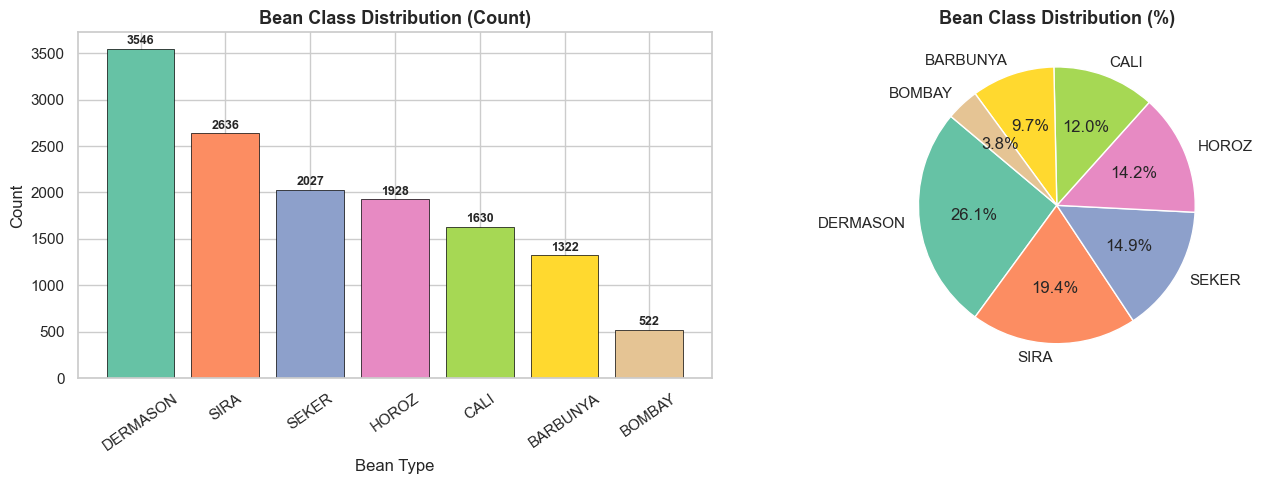


Observation: DERMASON is the most frequent class while BOMBAY is the least.
There is a noticeable class imbalance that should be addressed before modelling.


In [9]:
class_counts = df['Class'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette('Set2', n_colors=len(class_counts))
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Bean Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Bean Type')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=9)
axes[0].tick_params(axis='x', rotation=35)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes[1].set_title('Bean Class Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nObservation: DERMASON is the most frequent class while BOMBAY is the least.')
print('There is a noticeable class imbalance that should be addressed before modelling.')

### 2.2  Feature Distributions — Histograms

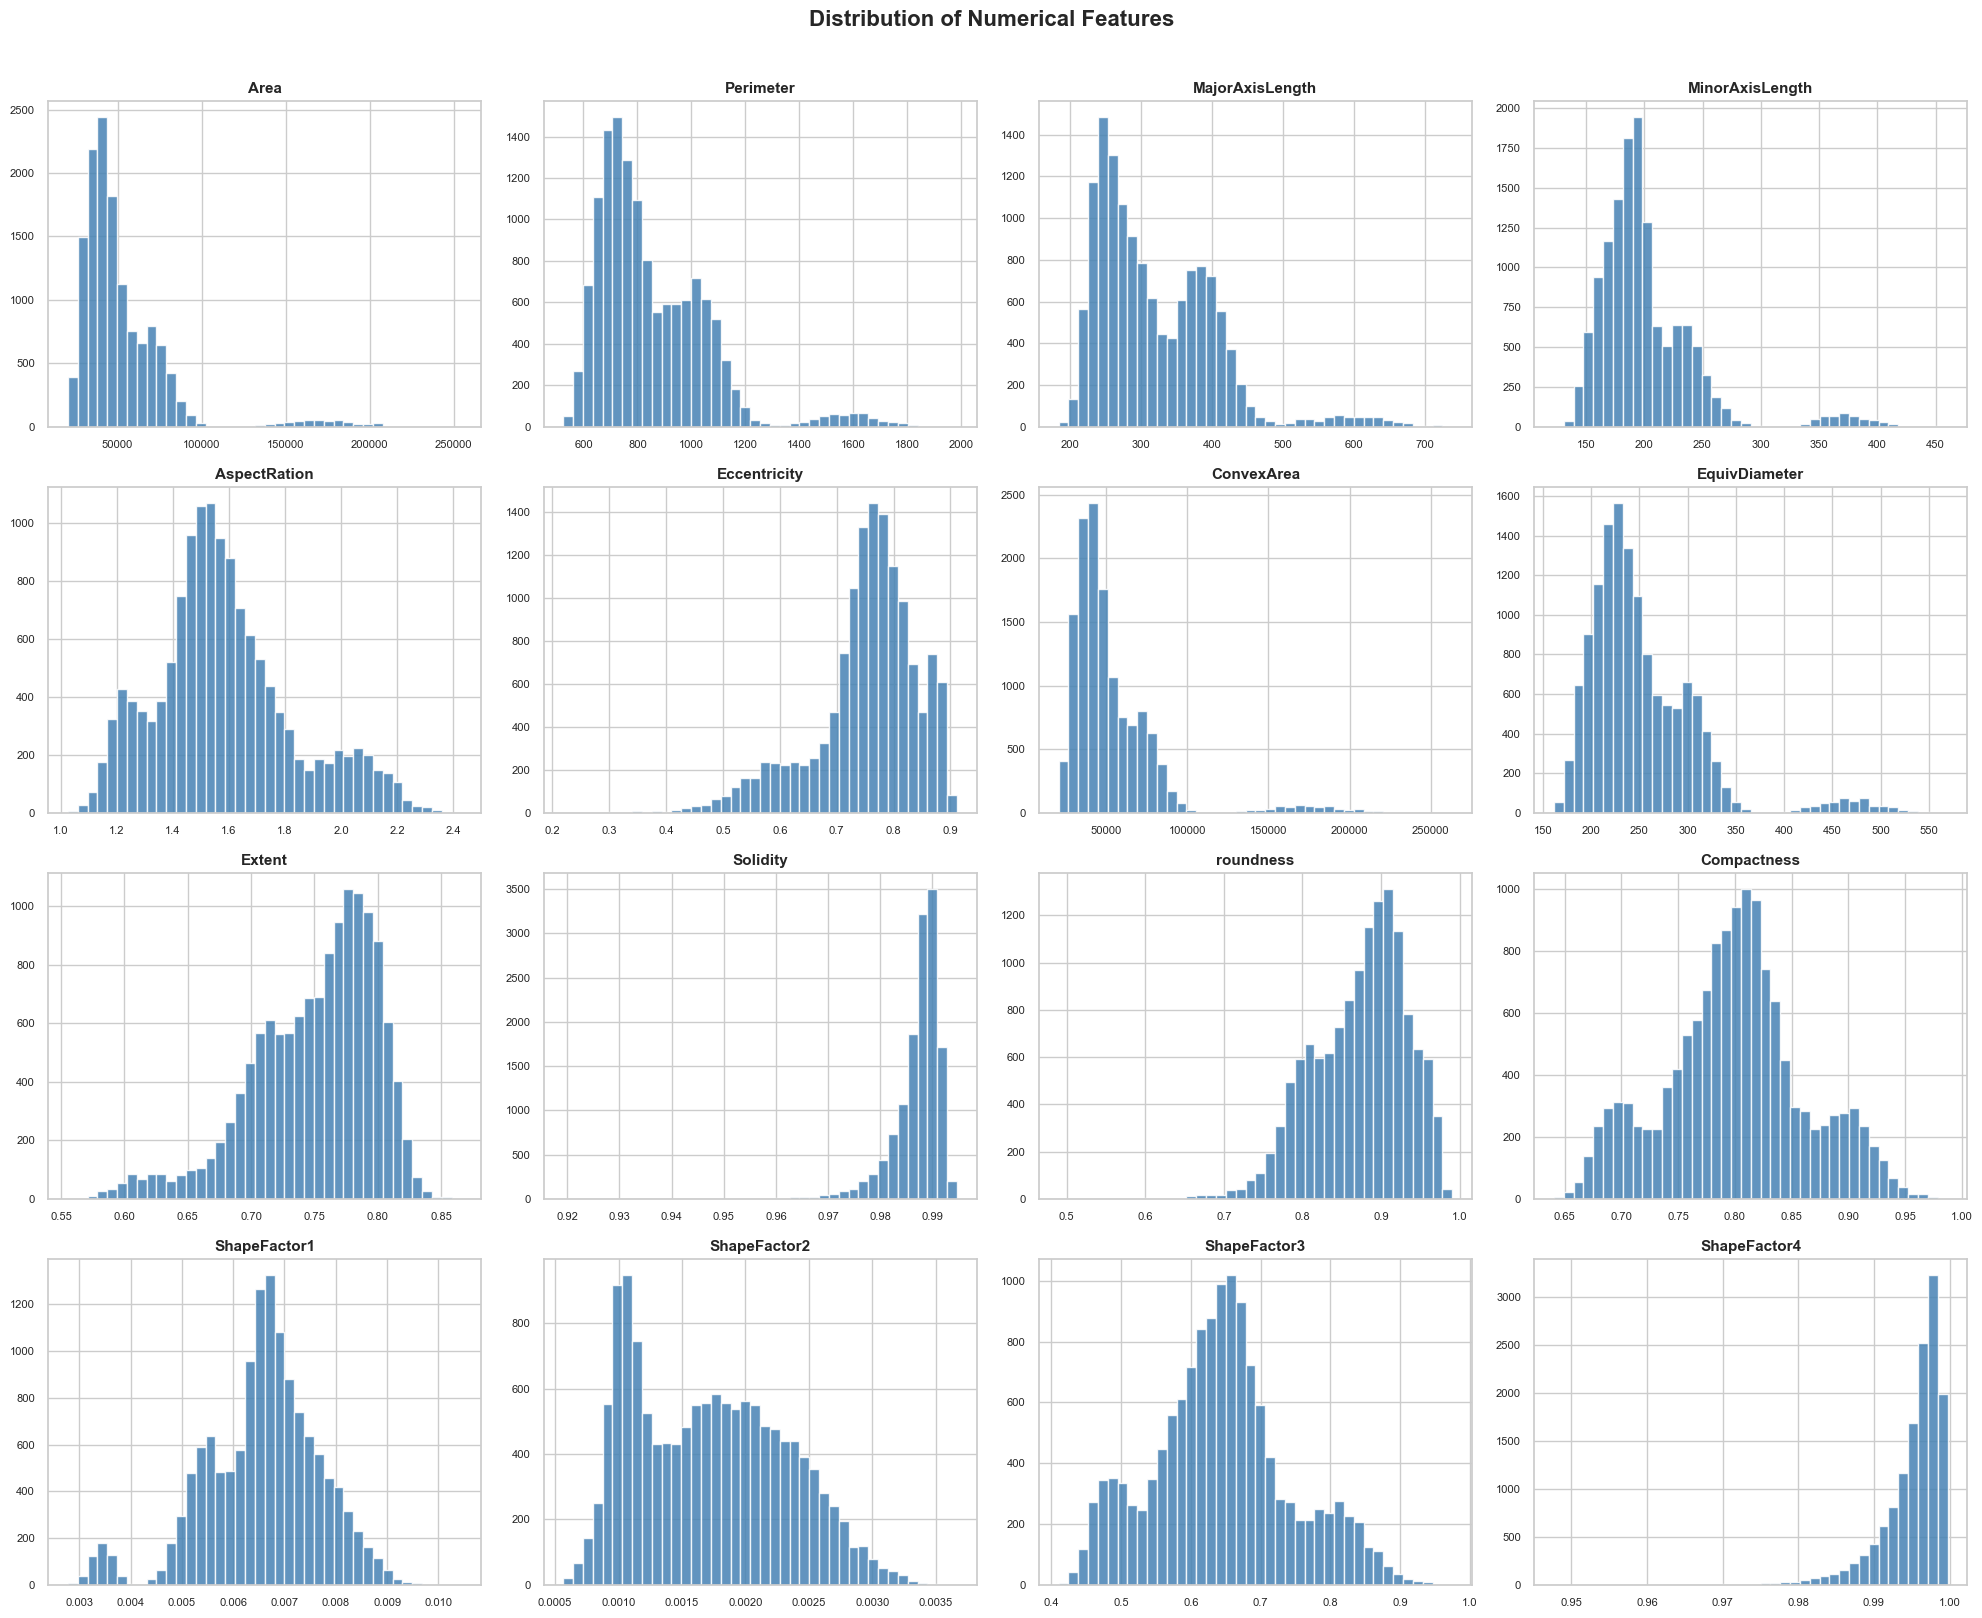

In [10]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    df[col].hist(bins=40, ax=axes[idx], color='steelblue', edgecolor='white', alpha=0.85)
    axes[idx].set_title(col, fontsize=11, fontweight='bold')
    axes[idx].tick_params(labelsize=8)

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.3  Box Plots — Detecting Spread & Outliers

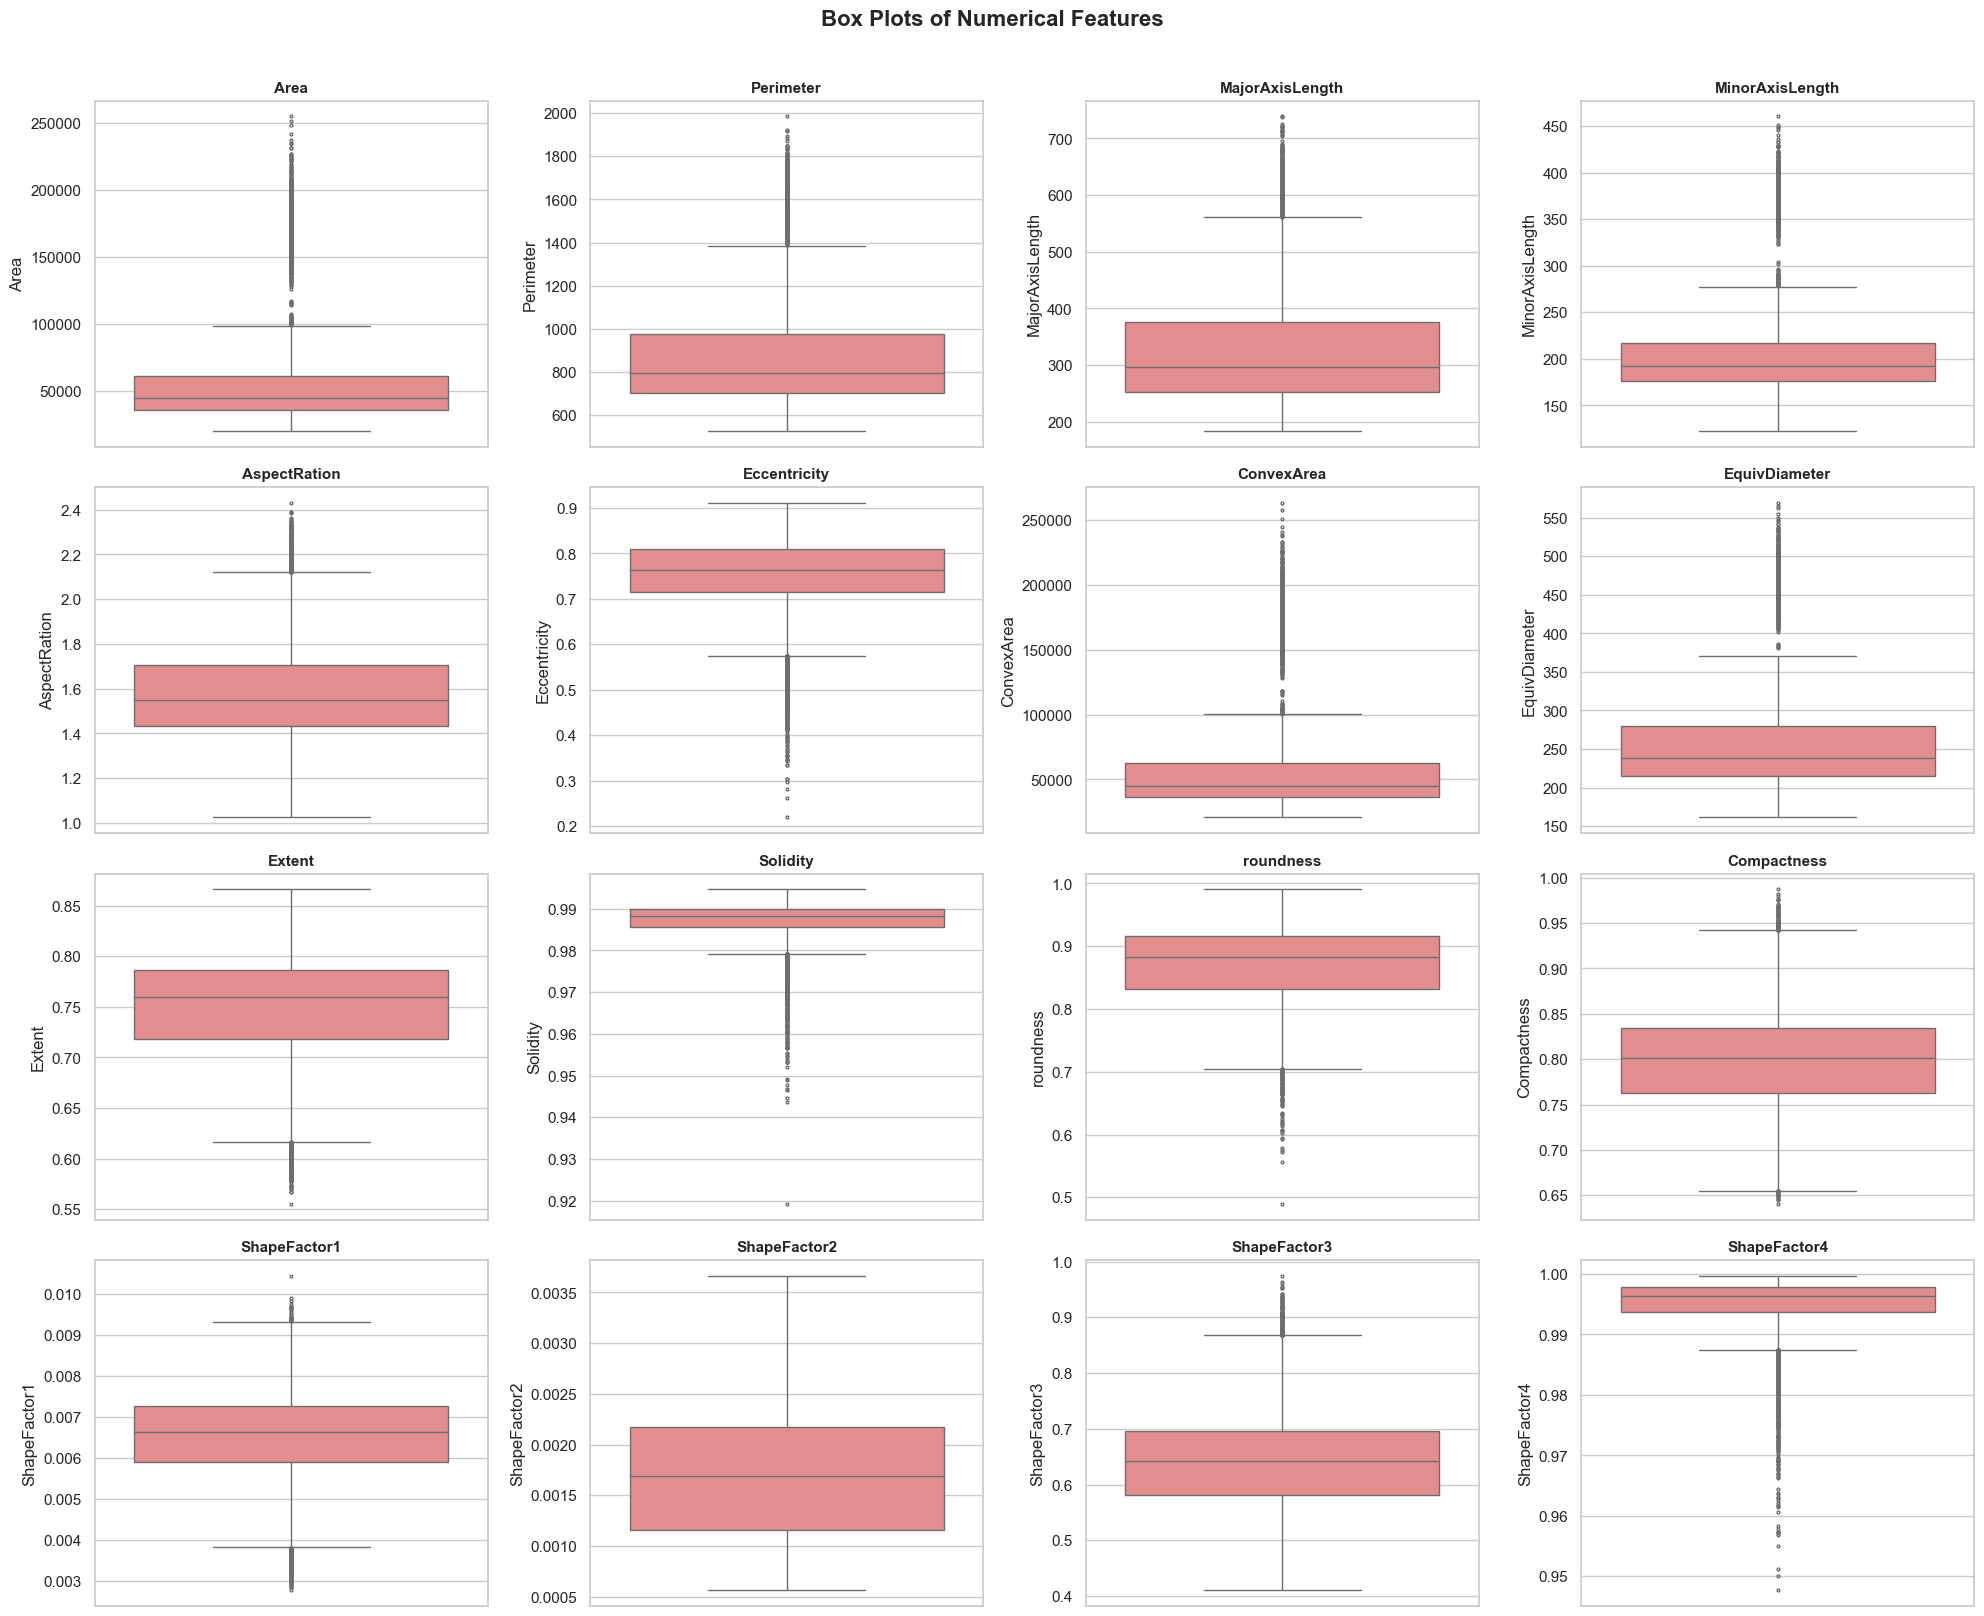

In [11]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    sns.boxplot(data=df, y=col, ax=axes[idx], color='lightcoral', fliersize=2)
    axes[idx].set_title(col, fontsize=11, fontweight='bold')

plt.suptitle('Box Plots of Numerical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.4  Correlation Heatmap

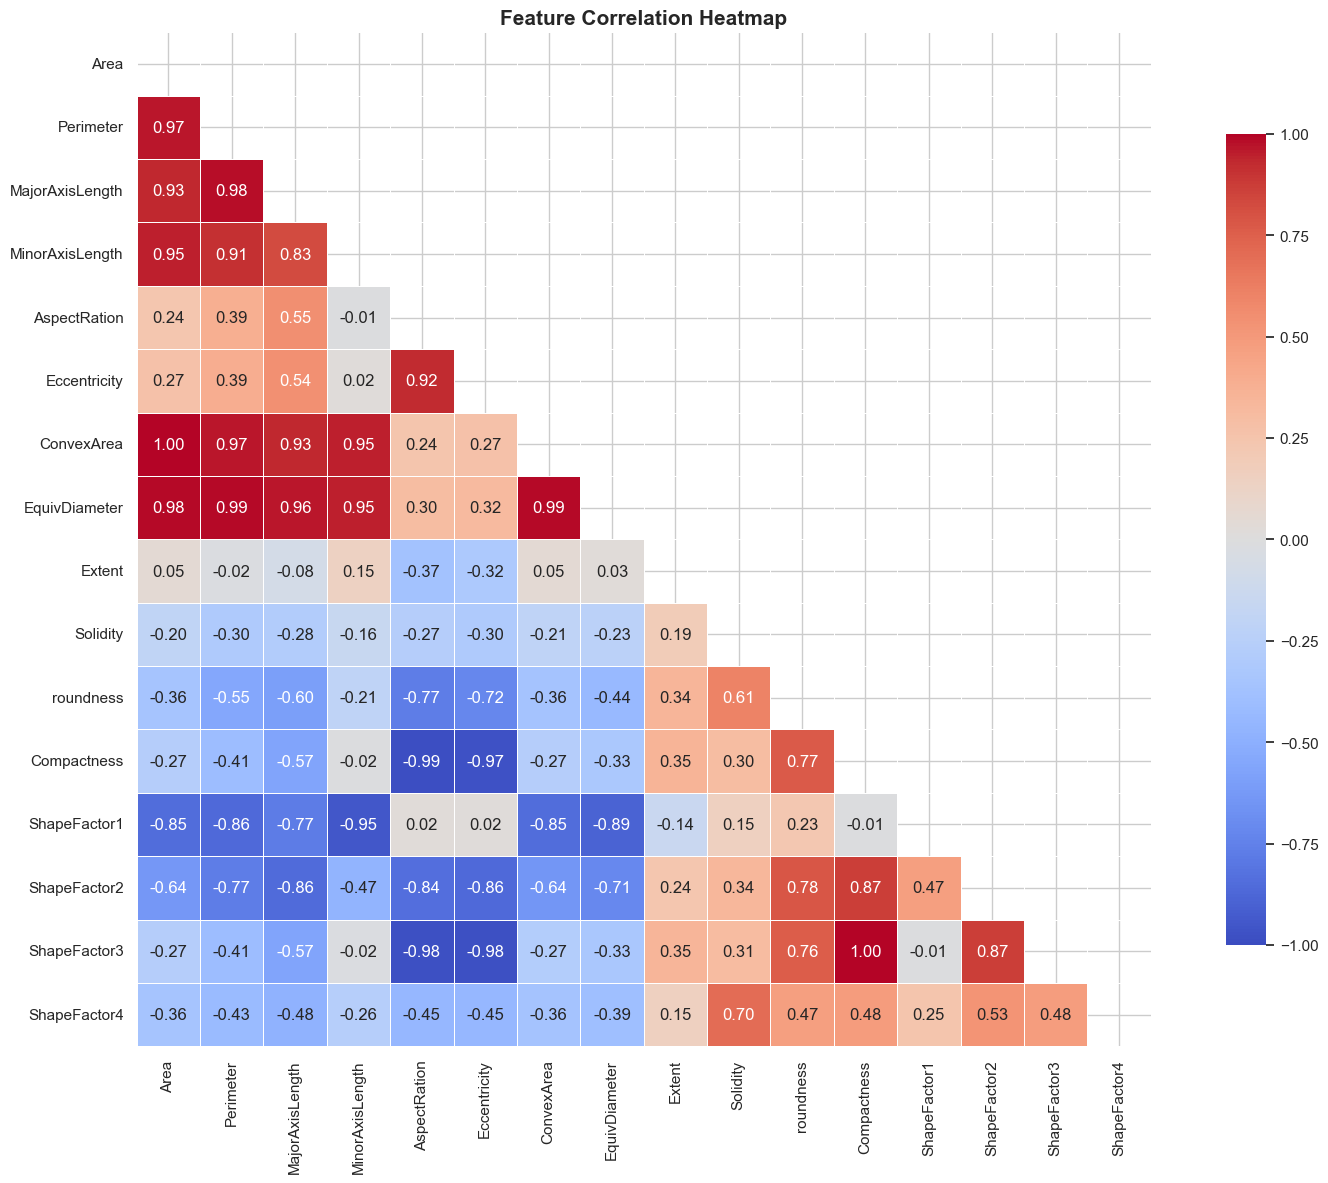


Key observations from correlation analysis:
  • Area, Perimeter, MajorAxisLength, ConvexArea, EquivDiameter are highly correlated (>0.9).
  • Compactness and ShapeFactor3 are very strongly correlated.
  • Eccentricity and AspectRation show strong positive correlation.


In [12]:
plt.figure(figsize=(16, 12))
corr_matrix = df[num_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey observations from correlation analysis:')
print('  • Area, Perimeter, MajorAxisLength, ConvexArea, EquivDiameter are highly correlated (>0.9).')
print('  • Compactness and ShapeFactor3 are very strongly correlated.')
print('  • Eccentricity and AspectRation show strong positive correlation.')

### 2.5  Pair Plot (Subset of Features)

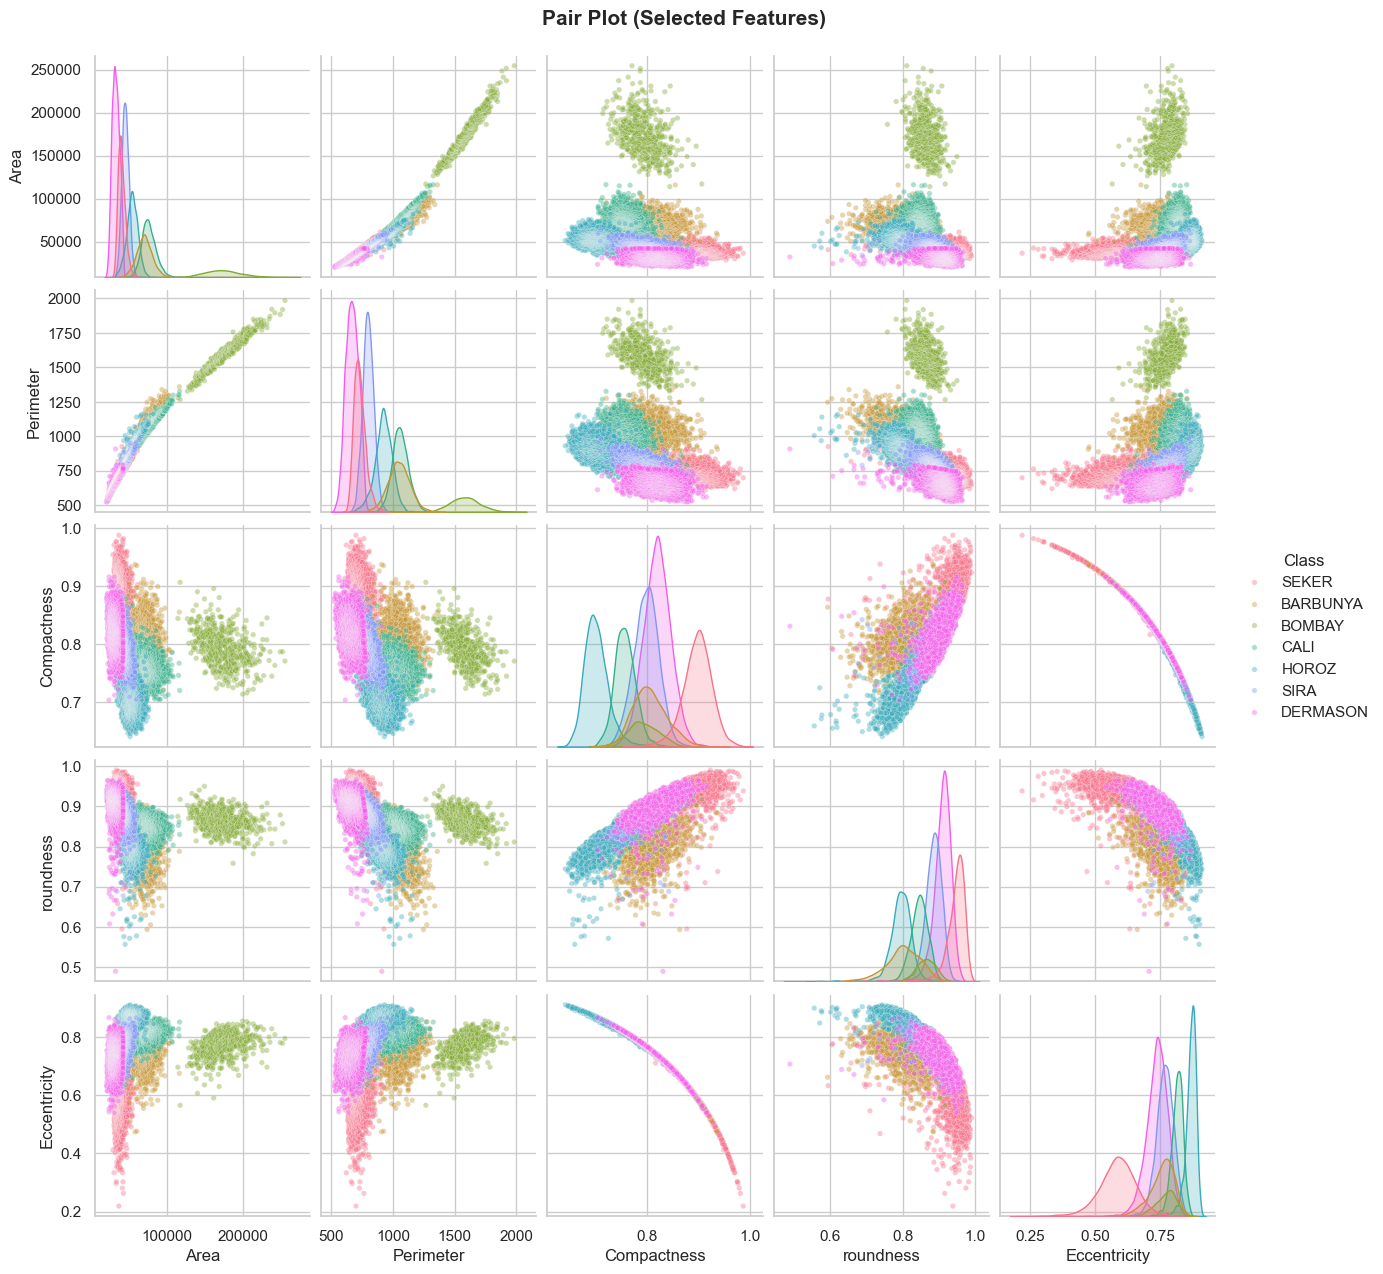

Observation: BOMBAY beans are visibly separable (larger area/perimeter).
Other classes overlap significantly — advanced models will be needed.


In [13]:
# Using a subset of 5 features to keep the pair plot readable
subset_features = ['Area', 'Perimeter', 'Compactness', 'roundness', 'Eccentricity', 'Class']

g = sns.pairplot(df[subset_features], hue='Class', palette='husl',
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15})
g.figure.suptitle('Pair Plot (Selected Features)', y=1.02, fontsize=15, fontweight='bold')
plt.show()

print('Observation: BOMBAY beans are visibly separable (larger area/perimeter).')
print('Other classes overlap significantly — advanced models will be needed.')

### 2.6  Feature-wise Box Plots by Bean Class

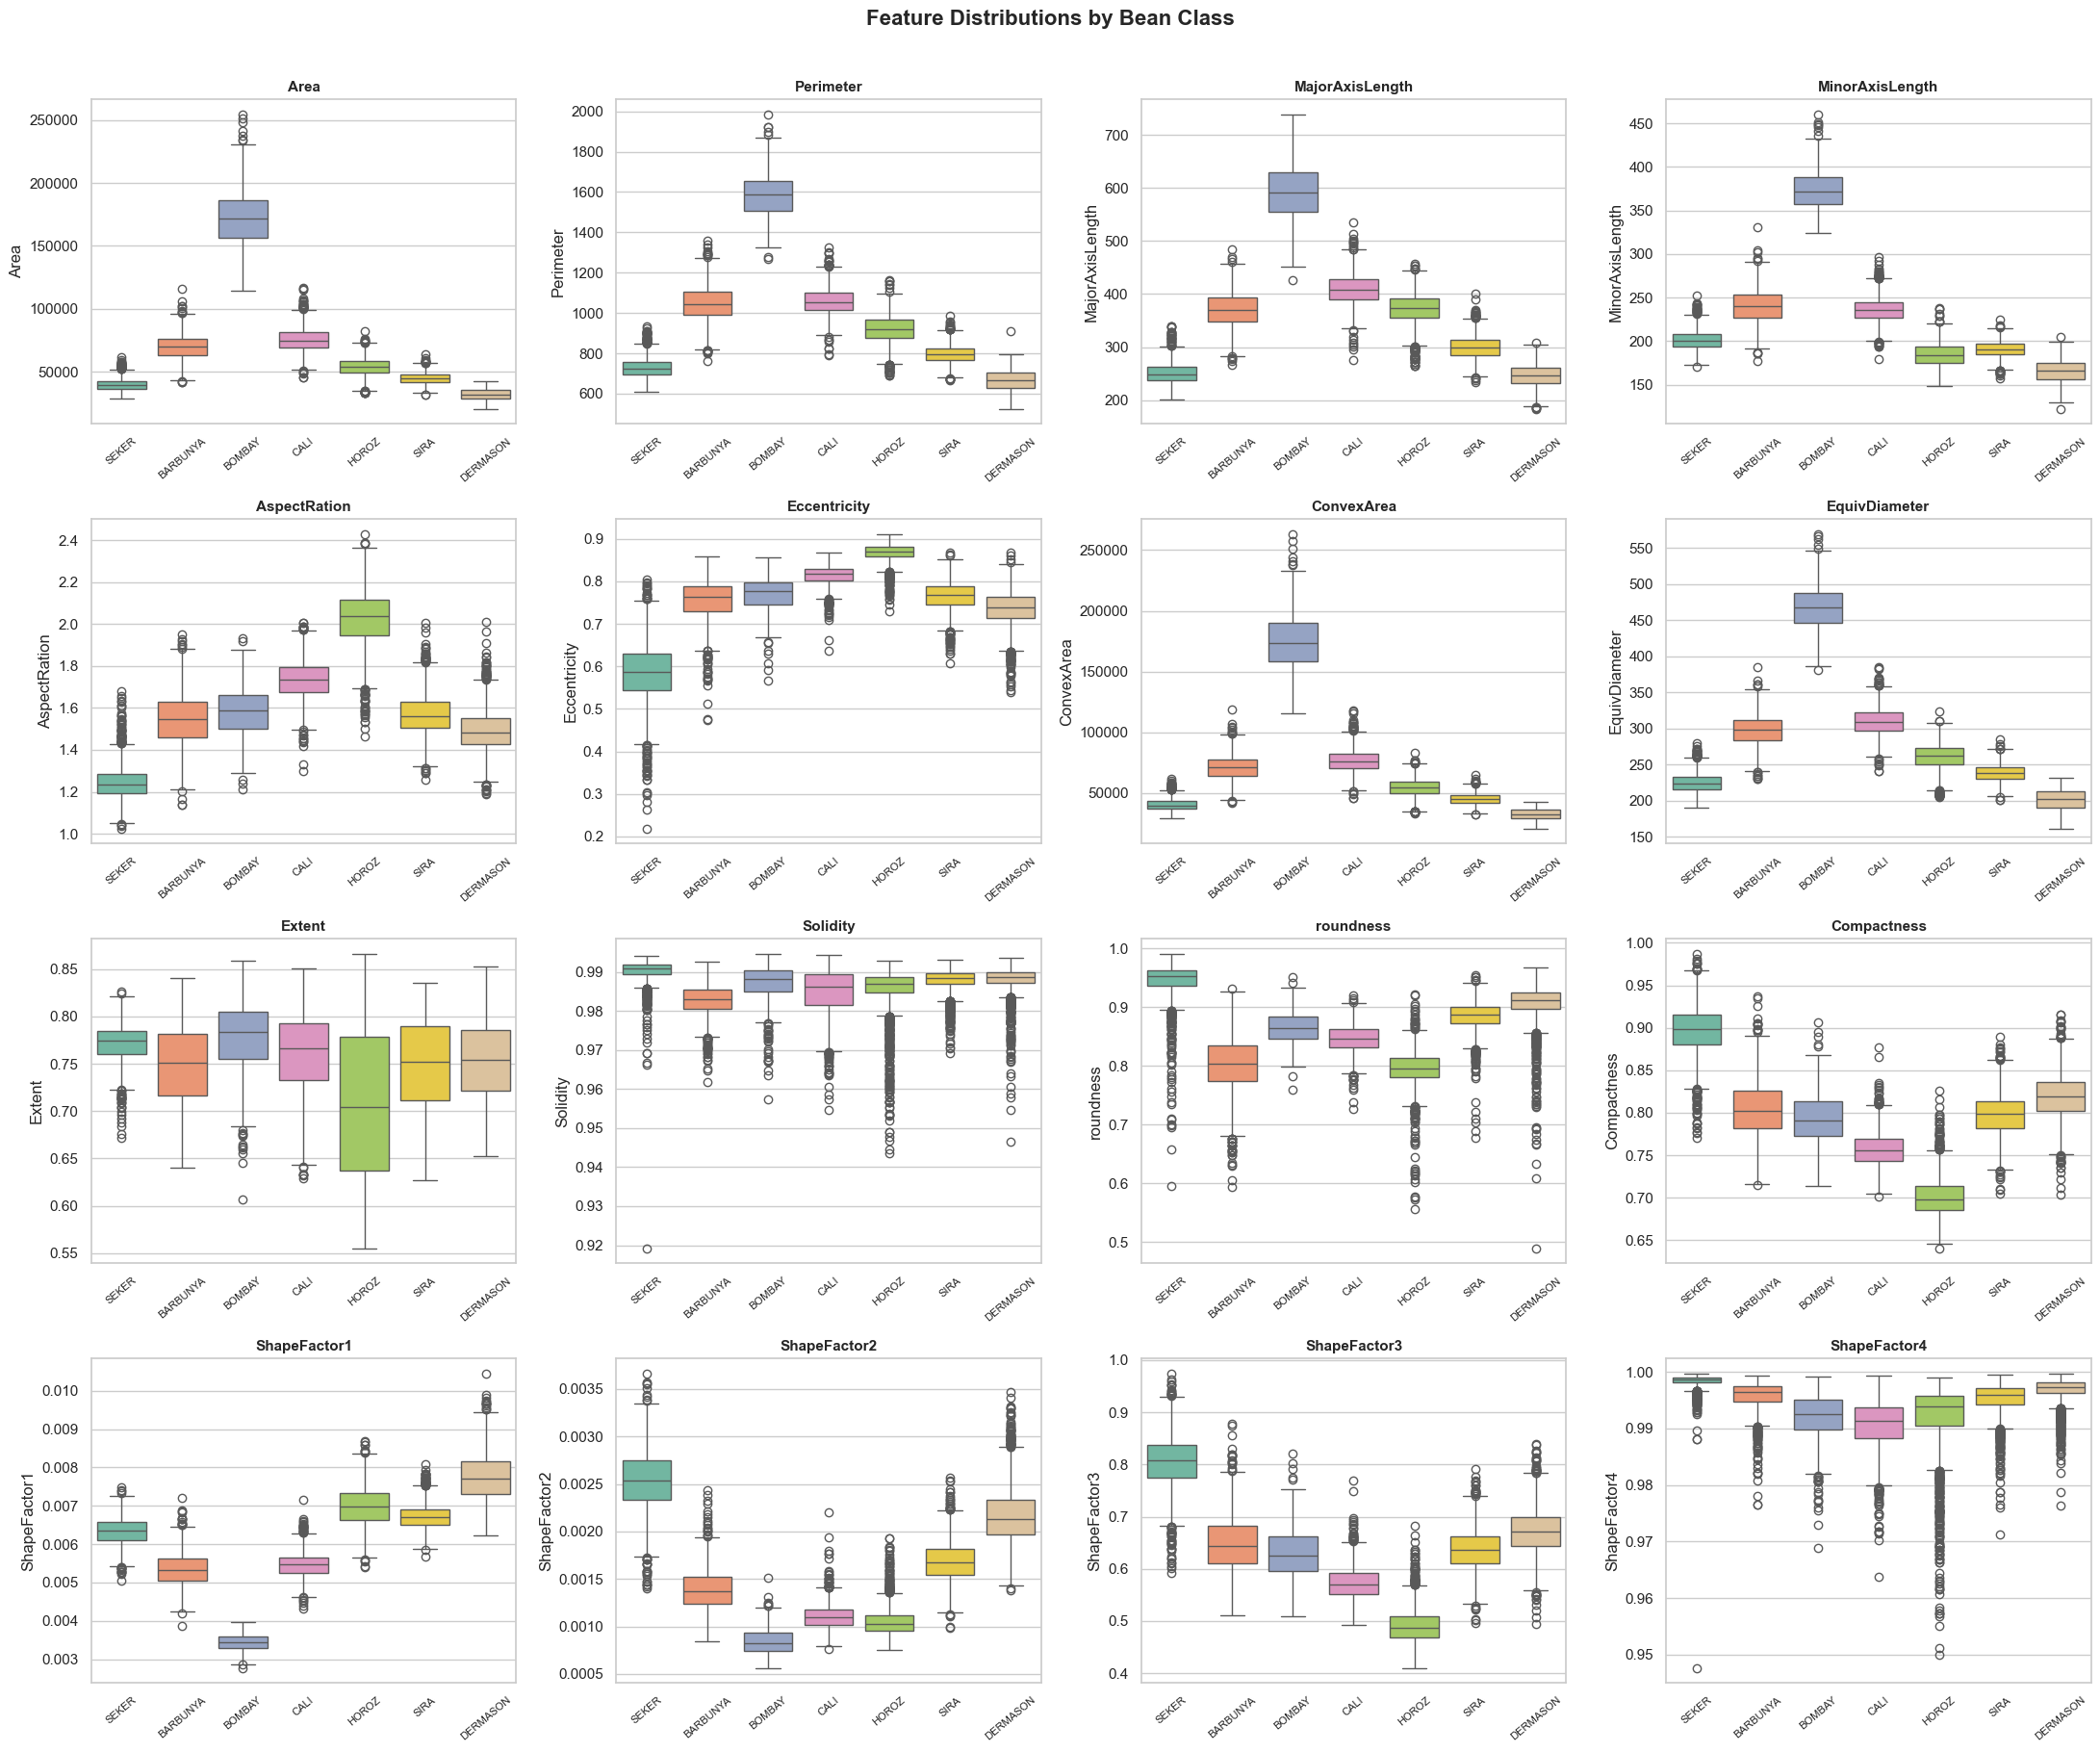

In [14]:
fig, axes = plt.subplots(4, 4, figsize=(22, 18))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Class', y=col, ax=axes[idx], palette='Set2')
    axes[idx].set_title(col, fontsize=11, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=40, labelsize=8)
    axes[idx].set_xlabel('')

plt.suptitle('Feature Distributions by Bean Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.7  EDA Summary

| Finding | Detail |
|---|---|
| **Class Imbalance** | DERMASON has ~7× more samples than BOMBAY — imbalance handling needed |
| **High Correlations** | Several feature groups are strongly correlated (>0.9) |
| **Outliers** | Multiple features exhibit outliers (visible in box plots) |
| **Separability** | BOMBAY class is well-separated; other classes overlap substantially |
| **Skewness** | Some features (Area, ConvexArea) show right skew |

---
## Task 3: Missing Values & Outlier Treatment

### 3.1  Missing Values Check

In [15]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)
print(f'\nTotal missing values in the entire dataset: {df.isnull().sum().sum()}')
print('✓ No missing values found — no imputation required.')

                 Missing Count  Missing %
Area                         0        0.0
Perimeter                    0        0.0
MajorAxisLength              0        0.0
MinorAxisLength              0        0.0
AspectRation                 0        0.0
Eccentricity                 0        0.0
ConvexArea                   0        0.0
EquivDiameter                0        0.0
Extent                       0        0.0
Solidity                     0        0.0
roundness                    0        0.0
Compactness                  0        0.0
ShapeFactor1                 0        0.0
ShapeFactor2                 0        0.0
ShapeFactor3                 0        0.0
ShapeFactor4                 0        0.0
Class                        0        0.0

Total missing values in the entire dataset: 0
✓ No missing values found — no imputation required.


### 3.2  Outlier Detection using IQR Method

In [16]:
def count_outliers_iqr(data, columns):
    """Count outliers per feature using the IQR method."""
    outlier_info = {}
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_count = ((data[col] < lower) | (data[col] > upper)).sum()
        outlier_info[col] = {'Outliers': outlier_count, 'Pct': round(outlier_count / len(data) * 100, 2)}
    return pd.DataFrame(outlier_info).T

outlier_summary = count_outliers_iqr(df, num_cols)
print('Outlier Summary (IQR Method):')
outlier_summary

Outlier Summary (IQR Method):


,Outliers,Pct
Area,551.0,4.05
Perimeter,500.0,3.67
MajorAxisLength,379.0,2.78
MinorAxisLength,569.0,4.18
AspectRation,473.0,3.48
Eccentricity,843.0,6.19
ConvexArea,550.0,4.04
EquivDiameter,526.0,3.86
Extent,275.0,2.02
Solidity,778.0,5.72


### 3.3  Outlier Treatment — IQR Capping (Winsorization)

In [17]:
df_clean = df.copy()

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap the outliers instead of removing them (preserves sample count)
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

print(f'Shape before outlier treatment : {df.shape}')
print(f'Shape after outlier treatment  : {df_clean.shape}')
print('Outliers were capped (winsorized) using IQR boundaries.')

Shape before outlier treatment : (13611, 17)
Shape after outlier treatment  : (13611, 17)
Outliers were capped (winsorized) using IQR boundaries.


In [18]:
# Verify: re-check outlier counts after capping
outlier_after = count_outliers_iqr(df_clean, num_cols)
print('Outlier count after treatment:')
outlier_after

Outlier count after treatment:


,Outliers,Pct
Area,0.0,0.0
Perimeter,0.0,0.0
MajorAxisLength,0.0,0.0
MinorAxisLength,0.0,0.0
AspectRation,0.0,0.0
Eccentricity,0.0,0.0
ConvexArea,0.0,0.0
EquivDiameter,0.0,0.0
Extent,0.0,0.0
Solidity,0.0,0.0


---
## Task 4: Feature Engineering & Preprocessing

### 4.1  Check and Treat Skewness

In [19]:
skew_vals = df_clean[num_cols].skew().sort_values(ascending=False)
print('Skewness of each feature (before transformation):\n')
print(skew_vals)

# Highlight features with skewness beyond ±0.75
highly_skewed = skew_vals[abs(skew_vals) > 0.75]
print(f'\nFeatures with |skewness| > 0.75 : {list(highly_skewed.index)}')

Skewness of each feature (before transformation):

MajorAxisLength    0.971004
ConvexArea         0.963532
Perimeter          0.961668
Area               0.956989
EquivDiameter      0.832987
MinorAxisLength    0.727810
AspectRation       0.472940
ShapeFactor2       0.301226
ShapeFactor3       0.193072
Compactness        0.018794
ShapeFactor1      -0.329187
roundness         -0.492208
Eccentricity      -0.610125
Extent            -0.783295
Solidity          -0.844704
ShapeFactor4      -1.040172
dtype: float64

Features with |skewness| > 0.75 : ['MajorAxisLength', 'ConvexArea', 'Perimeter', 'Area', 'EquivDiameter', 'Extent', 'Solidity', 'ShapeFactor4']


In [20]:
# Apply log1p transformation to highly skewed features
for col in highly_skewed.index:
    if (df_clean[col] > 0).all():  # log only safe for positive values
        df_clean[col] = np.log1p(df_clean[col])

skew_after = df_clean[num_cols].skew().sort_values(ascending=False)
print('Skewness after transformation:\n')
print(skew_after)

Skewness after transformation:

MinorAxisLength    0.727810
Perimeter          0.512103
AspectRation       0.472940
MajorAxisLength    0.467097
EquivDiameter      0.445156
ConvexArea         0.332407
Area               0.325111
ShapeFactor2       0.301226
ShapeFactor3       0.193072
Compactness        0.018794
ShapeFactor1      -0.329187
roundness         -0.492208
Eccentricity      -0.610125
Solidity          -0.848154
Extent            -0.850560
ShapeFactor4      -1.042810
dtype: float64


### 4.2  Encode the Target Variable

In [21]:
le = LabelEncoder()
df_clean['Class_Encoded'] = le.fit_transform(df_clean['Class'])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Label Encoding Mapping:')
for bean, code in label_mapping.items():
    print(f'  {bean:12s} → {code}')

Label Encoding Mapping:
  BARBUNYA     → 0
  BOMBAY       → 1
  CALI         → 2
  DERMASON     → 3
  HOROZ        → 4
  SEKER        → 5
  SIRA         → 6


### 4.3  Feature Scaling (StandardScaler)

In [22]:
# Separate features and target
X = df_clean[num_cols].copy()
y = df_clean['Class_Encoded'].copy()

print(f'Feature matrix shape : {X.shape}')
print(f'Target vector shape  : {y.shape}')

Feature matrix shape : (13611, 16)
Target vector shape  : (13611,)


In [23]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('Features after Standard Scaling (mean ≈ 0, std ≈ 1):')
X_scaled.describe().loc[['mean', 'std']].round(4)

Features after Standard Scaling (mean ≈ 0, std ≈ 1):


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
mean,0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### 4.4  Train-Test Split (Stratified)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set     : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)')

print('\nClass distribution in train vs test (proportions):')
train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist  = y_test.value_counts(normalize=True).sort_index()
comparison = pd.DataFrame({'Train %': (train_dist*100).round(2), 'Test %': (test_dist*100).round(2)})
comparison.index = le.classes_
print(comparison)
print('\n✓ Stratified split preserves class proportions across train and test sets.')

Training set : 10888 samples (80.0%)
Test set     : 2723 samples (20.0%)

Class distribution in train vs test (proportions):
          Train %  Test %
BARBUNYA     9.71    9.73
BOMBAY       3.84    3.82
CALI        11.98   11.97
DERMASON    26.06   26.04
HOROZ       14.16   14.18
SEKER       14.89   14.91
SIRA        19.37   19.35

✓ Stratified split preserves class proportions across train and test sets.


---
## Task 5: Model Building — Multiple Classifiers

In [25]:
# Dictionary of models to evaluate
models = {
    'Logistic Regression'    : LogisticRegression(max_iter=2000, random_state=42),
    'Decision Tree'          : DecisionTreeClassifier(random_state=42),
    'Random Forest'          : RandomForestClassifier(n_estimators=150, random_state=42),
    'K-Nearest Neighbors'    : KNeighborsClassifier(n_neighbors=7),
    'Support Vector Machine' : SVC(kernel='rbf', random_state=42),
    'Gradient Boosting'      : GradientBoostingClassifier(n_estimators=150, random_state=42),
    'AdaBoost'               : AdaBoostClassifier(n_estimators=120, random_state=42),
    'Bagging Classifier'     : BaggingClassifier(n_estimators=100, random_state=42),
    'Extra Trees'            : ExtraTreesClassifier(n_estimators=150, random_state=42),
    'Gaussian Naive Bayes'   : GaussianNB()
}

In [26]:
results = []

for name, model in models.items():
    # Fit
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)
    
    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test, y_test_pred)
    f1        = f1_score(y_test, y_test_pred, average='weighted')
    
    overfit = 'Yes' if (train_acc - test_acc) > 0.03 else 'No'
    
    results.append({
        'Model': name,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'F1 Score (Weighted)': round(f1, 4),
        'Overfitting (Y/N)': overfit
    })
    
    print(f'{name:25s}  |  Train: {train_acc:.4f}  |  Test: {test_acc:.4f}  |  F1: {f1:.4f}  |  Overfit: {overfit}')

results_df = pd.DataFrame(results)
print('\n✓ All models trained and evaluated.')

Logistic Regression        |  Train: 0.9263  |  Test: 0.9243  |  F1: 0.9245  |  Overfit: No
Decision Tree              |  Train: 1.0000  |  Test: 0.8931  |  F1: 0.8928  |  Overfit: Yes
Random Forest              |  Train: 1.0000  |  Test: 0.9225  |  F1: 0.9224  |  Overfit: Yes
K-Nearest Neighbors        |  Train: 0.9360  |  Test: 0.9155  |  F1: 0.9157  |  Overfit: No
Support Vector Machine     |  Train: 0.9342  |  Test: 0.9254  |  F1: 0.9254  |  Overfit: No
Gradient Boosting          |  Train: 0.9740  |  Test: 0.9207  |  F1: 0.9206  |  Overfit: Yes
AdaBoost                   |  Train: 0.8388  |  Test: 0.8245  |  F1: 0.8129  |  Overfit: No
Bagging Classifier         |  Train: 1.0000  |  Test: 0.9174  |  F1: 0.9174  |  Overfit: Yes
Extra Trees                |  Train: 1.0000  |  Test: 0.9188  |  F1: 0.9189  |  Overfit: Yes
Gaussian Naive Bayes       |  Train: 0.8980  |  Test: 0.8994  |  F1: 0.8996  |  Overfit: No

✓ All models trained and evaluated.


### 5.1  Cross-Validation Scores

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
print('5-Fold Stratified Cross-Validation Scores:\n')

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    mean_cv = scores.mean()
    std_cv  = scores.std()
    cv_results.append({'Model': name, 'CV Mean Accuracy': round(mean_cv, 4), 'CV Std': round(std_cv, 4)})
    print(f'{name:25s}  |  Mean: {mean_cv:.4f}  ±  {std_cv:.4f}')

cv_df = pd.DataFrame(cv_results).sort_values('CV Mean Accuracy', ascending=False)
print('\nModels ranked by cross-validation accuracy:')
cv_df


5-Fold Stratified Cross-Validation Scores:

Logistic Regression        |  Mean: 0.9242  ±  0.0049
Decision Tree              |  Mean: 0.8950  ±  0.0071
Random Forest              |  Mean: 0.9245  ±  0.0053
K-Nearest Neighbors        |  Mean: 0.9240  ±  0.0052
Support Vector Machine     |  Mean: 0.9290  ±  0.0054
Gradient Boosting          |  Mean: 0.9268  ±  0.0038
AdaBoost                   |  Mean: 0.8567  ±  0.0213
Bagging Classifier         |  Mean: 0.9248  ±  0.0050
Extra Trees                |  Mean: 0.9228  ±  0.0060
Gaussian Naive Bayes       |  Mean: 0.8971  ±  0.0078

Models ranked by cross-validation accuracy:


,Model,CV Mean Accuracy,CV Std
4,Support Vector Machine,0.9290,0.0054
5,Gradient Boosting,0.9268,0.0038
7,Bagging Classifier,0.9248,0.0050
2,Random Forest,0.9245,0.0053
0,Logistic Regression,0.9242,0.0049
3,K-Nearest Neighbors,0.9240,0.0052
8,Extra Trees,0.9228,0.0060
9,Gaussian Naive Bayes,0.8971,0.0078
1,Decision Tree,0.8950,0.0071
6,AdaBoost,0.8567,0.0213


---
## Task 6: Handling Class Imbalance

In [28]:
print('Original class distribution in training set:')
print(y_train.value_counts().sort_index())

Original class distribution in training set:
Class_Encoded
0    1057
1     418
2    1304
3    2837
4    1542
5    1621
6    2109
Name: count, dtype: int64


### 6.1  SMOTE (Synthetic Minority Over-sampling Technique)

In [29]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'After SMOTE  —  Training samples: {X_train_smote.shape[0]} (was {X_train.shape[0]})')
print('\nClass distribution after SMOTE:')
print(pd.Series(y_train_smote).value_counts().sort_index())

After SMOTE  —  Training samples: 19859 (was 10888)

Class distribution after SMOTE:
Class_Encoded
0    2837
1    2837
2    2837
3    2837
4    2837
5    2837
6    2837
Name: count, dtype: int64


### 6.2  Random Oversampling

In [30]:
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

print(f'After Random Oversampling  —  Training samples: {X_train_ros.shape[0]}')
print('\nClass distribution after Random Oversampling:')
print(pd.Series(y_train_ros).value_counts().sort_index())

After Random Oversampling  —  Training samples: 19859

Class distribution after Random Oversampling:
Class_Encoded
0    2837
1    2837
2    2837
3    2837
4    2837
5    2837
6    2837
Name: count, dtype: int64


### 6.3  Class Weighting (built into the model)

In [31]:
# Random Forest with class_weight='balanced'
rf_balanced = RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42)
rf_balanced.fit(X_train, y_train)
y_pred_balanced = rf_balanced.predict(X_test)

print('Random Forest with class_weight="balanced":')
print(f'  Test Accuracy : {accuracy_score(y_test, y_pred_balanced):.4f}')
print(f'  F1 (weighted) : {f1_score(y_test, y_pred_balanced, average="weighted"):.4f}')

Random Forest with class_weight="balanced":
  Test Accuracy : 0.9196
  F1 (weighted) : 0.9195


### 6.4  Compare Imbalance Handling Techniques on Best Performing Models

In [32]:
# Train top 3 models on SMOTE data and compare
top_models = {
    'Random Forest'     : RandomForestClassifier(n_estimators=150, random_state=42),
    'Extra Trees'       : ExtraTreesClassifier(n_estimators=150, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=150, random_state=42),
    'SVM'               : SVC(kernel='rbf', random_state=42),
}

imbalance_results = []

for name, model in top_models.items():
    # ── Original ──
    model_orig = type(model)(**model.get_params())
    model_orig.fit(X_train, y_train)
    y_pred_orig = model_orig.predict(X_test)
    f1_orig = f1_score(y_test, y_pred_orig, average='weighted')
    
    # ── SMOTE ──
    model_smote = type(model)(**model.get_params())
    model_smote.fit(X_train_smote, y_train_smote)
    y_pred_smote = model_smote.predict(X_test)
    f1_smote = f1_score(y_test, y_pred_smote, average='weighted')
    
    # ── Random Oversampling ──
    model_ros = type(model)(**model.get_params())
    model_ros.fit(X_train_ros, y_train_ros)
    y_pred_ros = model_ros.predict(X_test)
    f1_ros = f1_score(y_test, y_pred_ros, average='weighted')
    
    imbalance_results.append({
        'Model': name,
        'F1 (Original)': round(f1_orig, 4),
        'F1 (SMOTE)': round(f1_smote, 4),
        'F1 (RandomOversampling)': round(f1_ros, 4)
    })

imb_df = pd.DataFrame(imbalance_results)
print('Comparison of Imbalance Handling Techniques (Weighted F1 Score):\n')
imb_df

Comparison of Imbalance Handling Techniques (Weighted F1 Score):



,Model,F1 (Original),F1 (SMOTE),F1 (RandomOversampling)
0,Random Forest,0.9224,0.9228,0.9188
1,Extra Trees,0.9189,0.9152,0.9170
2,Gradient Boosting,0.9206,0.9210,0.9217
3,SVM,0.9254,0.9252,0.9256


---
## Task 7: Model Evaluation & Overfitting Check

### 7.1  Detailed Classification Reports for All Models

In [33]:
# Re-train models on SMOTE data for final evaluation (since SMOTE generally helps)
print('='*80)
print('Classification Reports — Trained on SMOTE-resampled data')
print('='*80)

trained_models_smote = {}

for name, model in models.items():
    m = type(model)(**model.get_params())
    m.fit(X_train_smote, y_train_smote)
    y_pred = m.predict(X_test)
    trained_models_smote[name] = m
    
    print(f'\n── {name} ──')
    print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification Reports — Trained on SMOTE-resampled data

── Logistic Regression ──
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.92      0.93       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.94       326
    DERMASON       0.94      0.87      0.91       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.92      0.96      0.94       406
        SIRA       0.83      0.89      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723


── Decision Tree ──
              precision    recall  f1-score   support

    BARBUNYA       0.88      0.88      0.88       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.90      0.90       326
    DERMASON       0.89      0.89      0.89       709
       HOROZ       0.93    

### 7.2  Confusion Matrices for Top Models

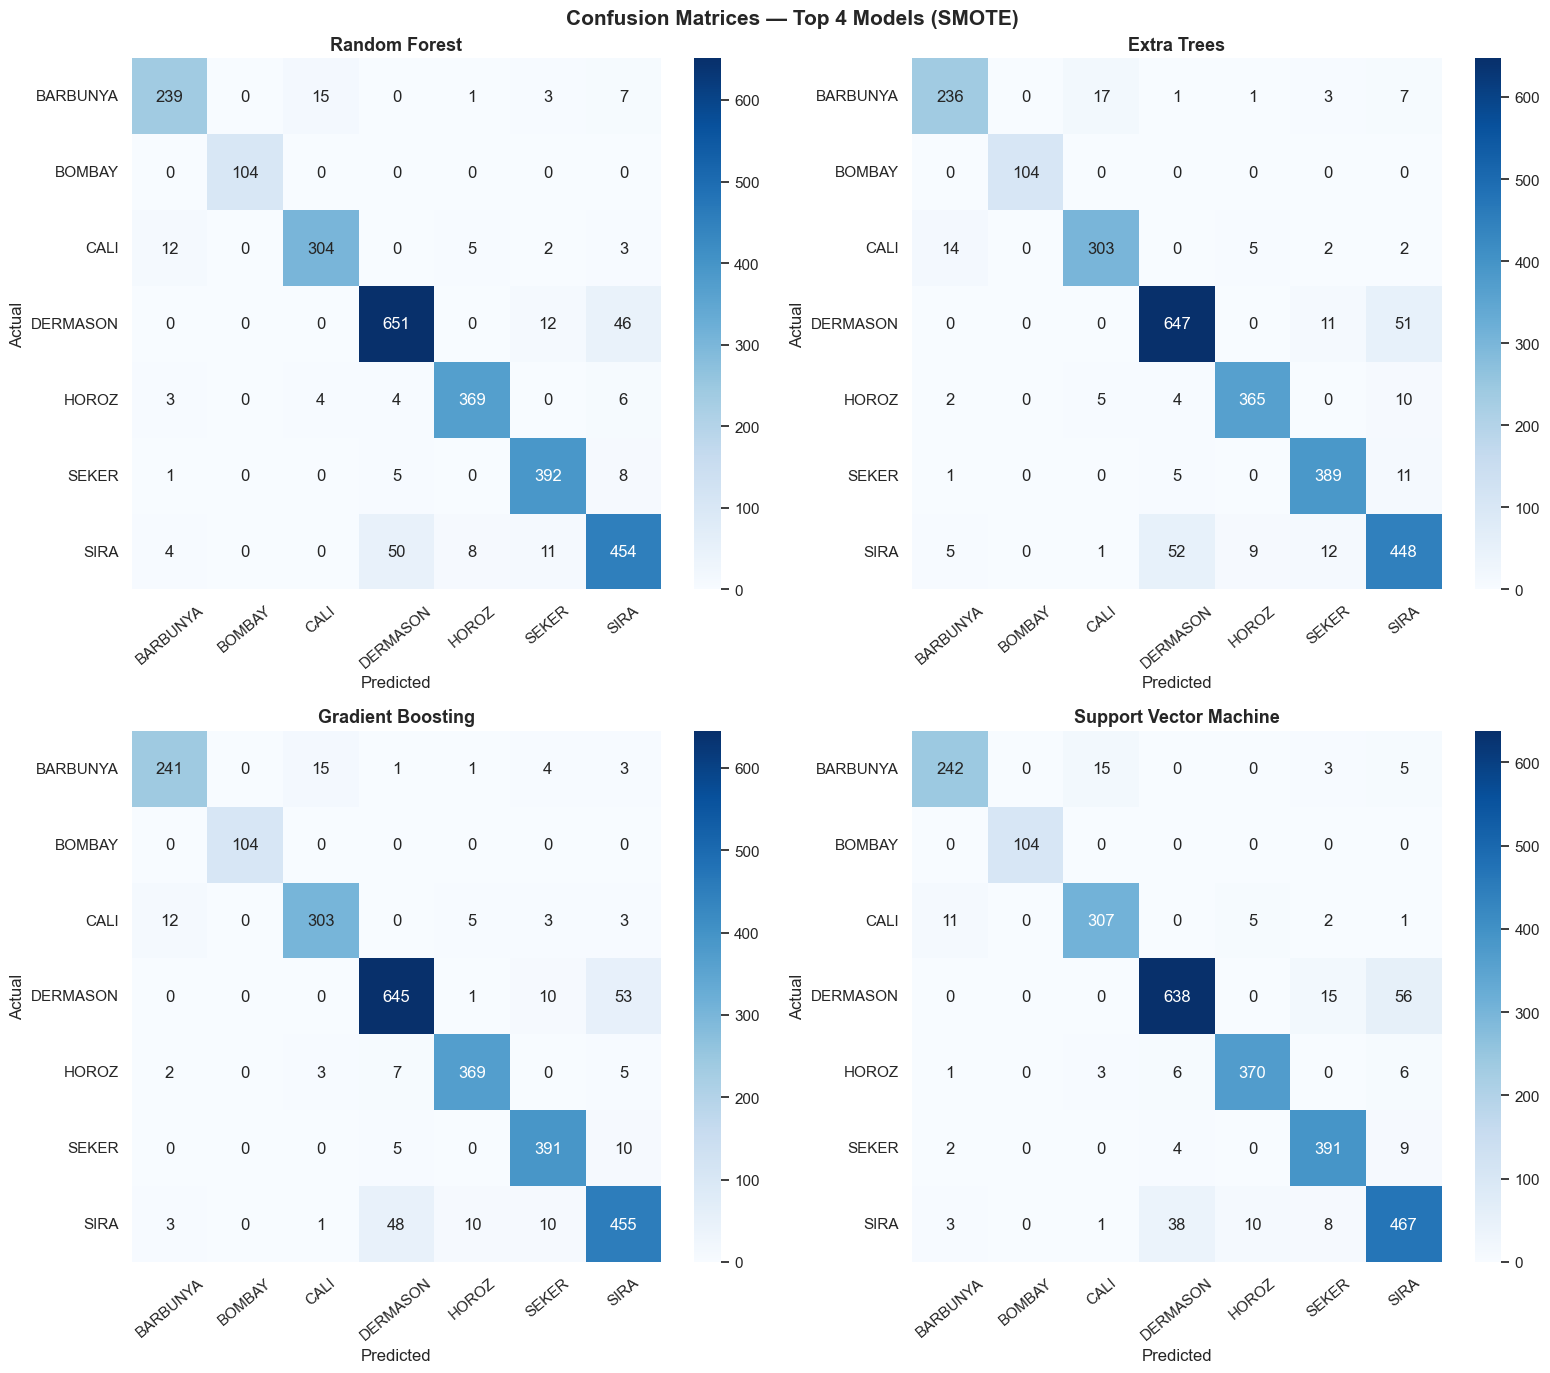

In [34]:
top_names = ['Random Forest', 'Extra Trees', 'Gradient Boosting', 'Support Vector Machine']

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, name in enumerate(top_names):
    m = trained_models_smote[name]
    y_pred = m.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')
    axes[idx].tick_params(axis='x', rotation=40)

plt.suptitle('Confusion Matrices — Top 4 Models (SMOTE)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3  Overfitting Analysis

In [35]:
overfit_check = []

for name, m in trained_models_smote.items():
    train_pred = m.predict(X_train_smote)
    test_pred  = m.predict(X_test)
    
    tr_acc = accuracy_score(y_train_smote, train_pred)
    te_acc = accuracy_score(y_test, test_pred)
    gap    = tr_acc - te_acc
    
    overfit_check.append({
        'Model': name,
        'Train Accuracy': round(tr_acc, 4),
        'Test Accuracy': round(te_acc, 4),
        'Gap': round(gap, 4),
        'Overfitting?': 'Yes' if gap > 0.03 else 'No'
    })

overfit_df = pd.DataFrame(overfit_check)
print('Overfitting Check — Train vs Test Accuracy:\n')
overfit_df

Overfitting Check — Train vs Test Accuracy:



,Model,Train Accuracy,Test Accuracy,Gap,Overfitting?
0,Logistic Regression,0.9410,0.9185,0.0226,No
1,Decision Tree,1.0000,0.8931,0.1069,Yes
2,Random Forest,1.0000,0.9229,0.0771,Yes
3,K-Nearest Neighbors,0.9628,0.9122,0.0506,Yes
4,Support Vector Machine,0.9484,0.9251,0.0233,No
5,Gradient Boosting,0.9780,0.9210,0.0570,Yes
6,AdaBoost,0.8676,0.8358,0.0317,Yes
7,Bagging Classifier,1.0000,0.9207,0.0793,Yes
8,Extra Trees,1.0000,0.9152,0.0848,Yes
9,Gaussian Naive Bayes,0.9106,0.8983,0.0123,No


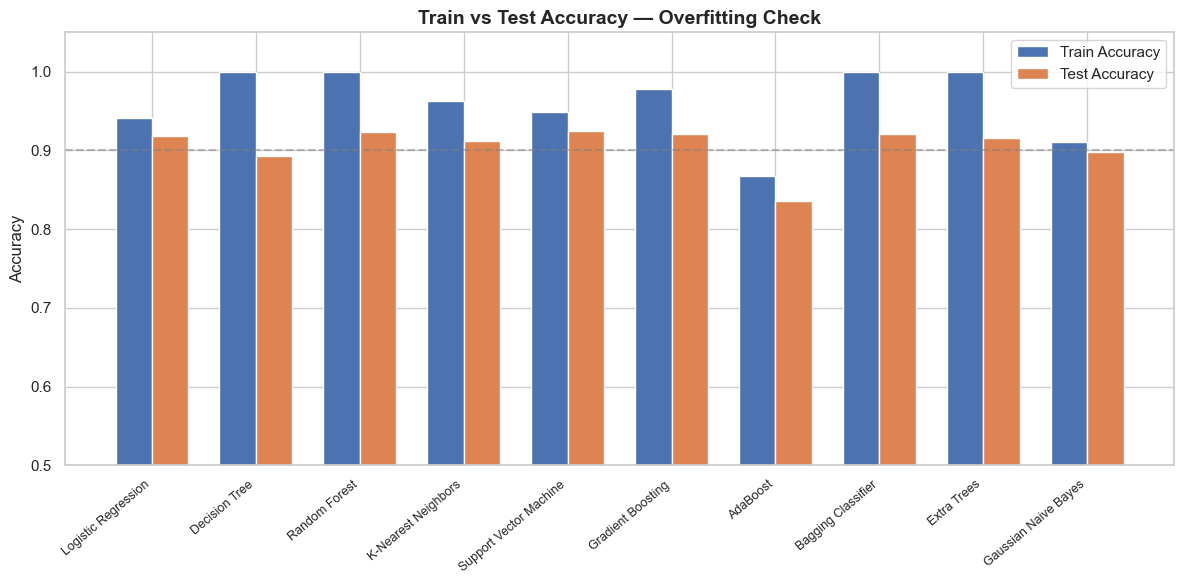

In [36]:
# Visual comparison of Train vs Test accuracy
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(overfit_df))
width = 0.35

bars1 = ax.bar(x - width/2, overfit_df['Train Accuracy'], width, label='Train Accuracy', color='#4C72B0')
bars2 = ax.bar(x + width/2, overfit_df['Test Accuracy'], width, label='Test Accuracy', color='#DD8452')

ax.set_xticks(x)
ax.set_xticklabels(overfit_df['Model'], rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy — Overfitting Check', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0.5, 1.05)
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='0.9 baseline')

plt.tight_layout()
plt.show()

---
## Task 8: Hyperparameter Tuning

### 8.1  Random Forest — GridSearchCV

In [37]:
import time

rf_start = time.time()

# Optimized Random Forest tuning — reduced parameters for faster execution
rf_params = {
    'n_estimators': [150, 200],
    'max_depth': [20, 25],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_smote, y_train_smote)

rf_time = time.time() - rf_start

print(f'\nBest Parameters : {rf_grid.best_params_}')
print(f'Best CV F1 Score: {rf_grid.best_score_:.4f}')
print(f'\n⏱️  Random Forest tuning time: {rf_time/60:.2f} minutes')

Fitting 2 folds for each of 8 candidates, totalling 16 fits

Best Parameters : {'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1 Score: 0.9504

⏱️  Random Forest tuning time: 17.17 minutes


In [38]:
# Evaluate tuned Random Forest on test set
rf_best = rf_grid.best_estimator_
y_pred_rf_tuned = rf_best.predict(X_test)

print('Tuned Random Forest — Test Set Performance:')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_rf_tuned):.4f}')
print(f'  F1 Score : {f1_score(y_test, y_pred_rf_tuned, average="weighted"):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_rf_tuned, target_names=le.classes_))

Tuned Random Forest — Test Set Performance:
  Accuracy : 0.9218
  F1 Score : 0.9217

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.92      0.90      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.93      0.93       326
    DERMASON       0.92      0.92      0.92       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.93      0.97      0.95       406
        SIRA       0.87      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



### 8.2  Extra Trees — RandomizedSearchCV

In [39]:
import time

et_start = time.time()

# Optimized Extra Trees tuning — reduced iterations and CV folds
et_params = {
    'n_estimators': [150, 250],
    'max_depth': [20, 25],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1],
    'max_features': ['sqrt', 'log2']
}

et_random = RandomizedSearchCV(
    ExtraTreesClassifier(random_state=42),
    param_distributions=et_params,
    n_iter=15,
    cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

et_random.fit(X_train_smote, y_train_smote)

et_time = time.time() - et_start

print(f'\nBest Parameters : {et_random.best_params_}')
print(f'Best CV F1 Score: {et_random.best_score_:.4f}')
print(f'\n⏱️  Extra Trees tuning time: {et_time/60:.2f} minutes')

Fitting 2 folds for each of 15 candidates, totalling 30 fits

Best Parameters : {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 25}
Best CV F1 Score: 0.9516

⏱️  Extra Trees tuning time: 0.82 minutes


In [40]:
et_best = et_random.best_estimator_
y_pred_et_tuned = et_best.predict(X_test)

print('Tuned Extra Trees — Test Set Performance:')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_et_tuned):.4f}')
print(f'  F1 Score : {f1_score(y_test, y_pred_et_tuned, average="weighted"):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_et_tuned, target_names=le.classes_))

Tuned Extra Trees — Test Set Performance:
  Accuracy : 0.9148
  F1 Score : 0.9148

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.91      0.89      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.93      0.93       326
    DERMASON       0.91      0.91      0.91       709
       HOROZ       0.96      0.94      0.95       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.85      0.85      0.85       527

    accuracy                           0.91      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.91      0.91      0.91      2723



### 8.3  Gradient Boosting — GridSearchCV

In [41]:
import time

start_time = time.time()

# Faster Gradient Boosting tuning — reduced search space for efficiency
gb_params = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [5, 6],
    'min_samples_split': [2],
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=gb_params,
    cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train_smote, y_train_smote)

elapsed_time = time.time() - start_time
print(f'\n⏱️  Execution time: {elapsed_time/60:.2f} minutes ({elapsed_time:.0f} seconds)')

print(f'\nBest Parameters : {gb_grid.best_params_}')
print(f'Best CV F1 Score: {gb_grid.best_score_:.4f}')



Fitting 2 folds for each of 8 candidates, totalling 16 fits

⏱️  Execution time: 18.52 minutes (1111 seconds)

Best Parameters : {'learning_rate': 0.1, 'max_depth': 6, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1 Score: 0.9521


In [42]:
gb_best = gb_grid.best_estimator_
y_pred_gb_tuned = gb_best.predict(X_test)

print('Tuned Gradient Boosting — Test Set Performance:')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_gb_tuned):.4f}')
print(f'  F1 Score : {f1_score(y_test, y_pred_gb_tuned, average="weighted"):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_gb_tuned, target_names=le.classes_))

Tuned Gradient Boosting — Test Set Performance:
  Accuracy : 0.9229
  F1 Score : 0.9228

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.93      0.94       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.95      0.96      0.96       386
       SEKER       0.94      0.97      0.96       406
        SIRA       0.86      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



---
## Task 9: Model Comparison Table

In [43]:
# Build the final comparison table incorporating tuned models
final_comparison = []

# Re-evaluate all models on SMOTE data for consistency
all_final_models = {
    'Logistic Regression'    : LogisticRegression(max_iter=2000, random_state=42),
    'Decision Tree'          : DecisionTreeClassifier(random_state=42),
    'Random Forest (Tuned)'  : rf_best,
    'K-Nearest Neighbors'    : KNeighborsClassifier(n_neighbors=7),
    'SVM'                    : SVC(kernel='rbf', random_state=42),
    'Gradient Boosting (Tuned)' : gb_best,
    'AdaBoost'               : AdaBoostClassifier(n_estimators=120, random_state=42),
    'Bagging Classifier'     : BaggingClassifier(n_estimators=100, random_state=42),
    'Extra Trees (Tuned)'    : et_best,
    'Gaussian Naive Bayes'   : GaussianNB()
}

for name, model in all_final_models.items():
    # Tuned models are already fit
    if '(Tuned)' not in name:
        model.fit(X_train_smote, y_train_smote)
    
    y_tr_pred = model.predict(X_train_smote)
    y_te_pred = model.predict(X_test)
    
    tr_acc = accuracy_score(y_train_smote, y_tr_pred)
    te_acc = accuracy_score(y_test, y_te_pred)
    f1_val = f1_score(y_test, y_te_pred, average='weighted')
    gap    = tr_acc - te_acc
    
    final_comparison.append({
        'Model': name,
        'Train Accuracy': round(tr_acc, 4),
        'Test Accuracy': round(te_acc, 4),
        'F1 Score': round(f1_val, 4),
        'Overfitting (Y/N)': 'Yes' if gap > 0.03 else 'No'
    })

comparison_df = pd.DataFrame(final_comparison).sort_values('F1 Score', ascending=False).reset_index(drop=True)
comparison_df

,Model,Train Accuracy,Test Accuracy,F1 Score,Overfitting (Y/N)
0,SVM,0.9484,0.9251,0.9252,No
1,Gradient Boosting (Tuned),0.9995,0.9229,0.9228,Yes
2,Random Forest (Tuned),0.9999,0.9218,0.9217,Yes
3,Bagging Classifier,1.0000,0.9207,0.9206,Yes
4,Logistic Regression,0.9410,0.9185,0.9187,No
5,Extra Trees (Tuned),1.0000,0.9148,0.9148,Yes
6,K-Nearest Neighbors,0.9628,0.9122,0.9124,Yes
7,Gaussian Naive Bayes,0.9106,0.8983,0.8986,No
8,Decision Tree,1.0000,0.8931,0.8930,Yes
9,AdaBoost,0.8676,0.8358,0.8347,Yes


In [44]:
# Highlight the best model
best_row = comparison_df.iloc[0]
print('='*60)
print(f'🏆  BEST MODEL: {best_row["Model"]}')
print(f'    Train Accuracy : {best_row["Train Accuracy"]}')
print(f'    Test Accuracy  : {best_row["Test Accuracy"]}')
print(f'    F1 Score       : {best_row["F1 Score"]}')
print(f'    Overfitting    : {best_row["Overfitting (Y/N)"]}')
print('='*60)

🏆  BEST MODEL: SVM
    Train Accuracy : 0.9484
    Test Accuracy  : 0.9251
    F1 Score       : 0.9252
    Overfitting    : No


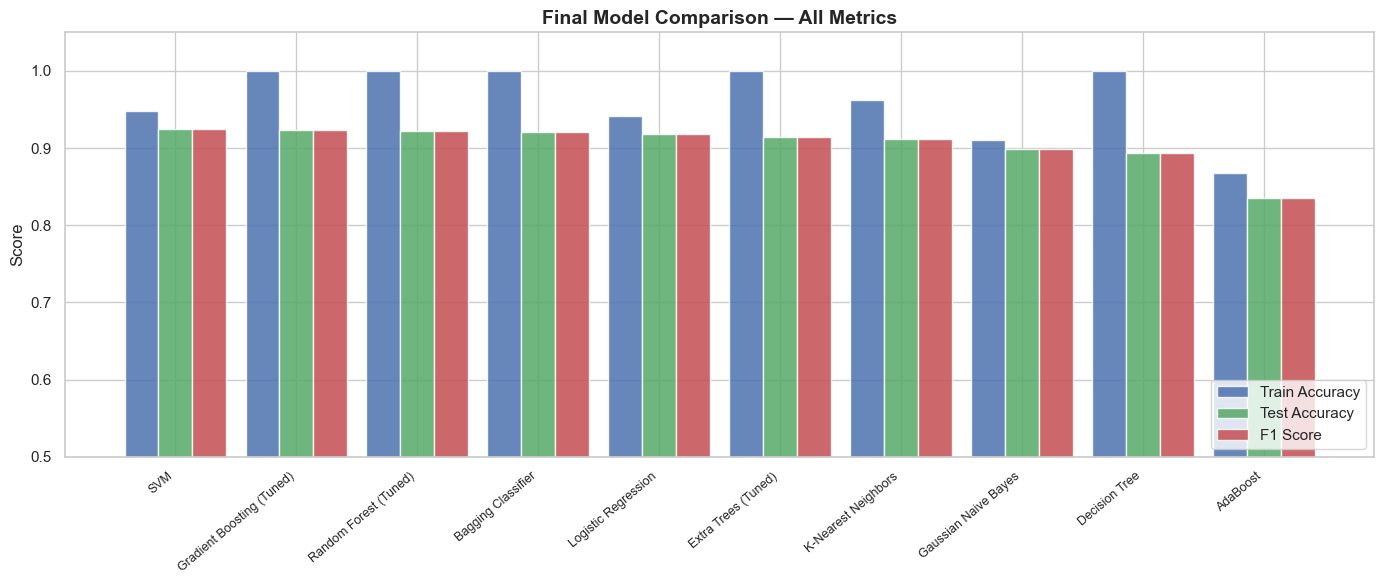

In [45]:
# Visual comparison bar chart
fig, ax = plt.subplots(figsize=(14, 6))

models_list = comparison_df['Model']
x = np.arange(len(models_list))
width = 0.28

ax.bar(x - width, comparison_df['Train Accuracy'], width, label='Train Accuracy', color='#4C72B0', alpha=0.85)
ax.bar(x, comparison_df['Test Accuracy'], width, label='Test Accuracy', color='#55A868', alpha=0.85)
ax.bar(x + width, comparison_df['F1 Score'], width, label='F1 Score', color='#C44E52', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Final Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.05)

plt.tight_layout()
plt.show()

### Final Confusion Matrix — Best Model

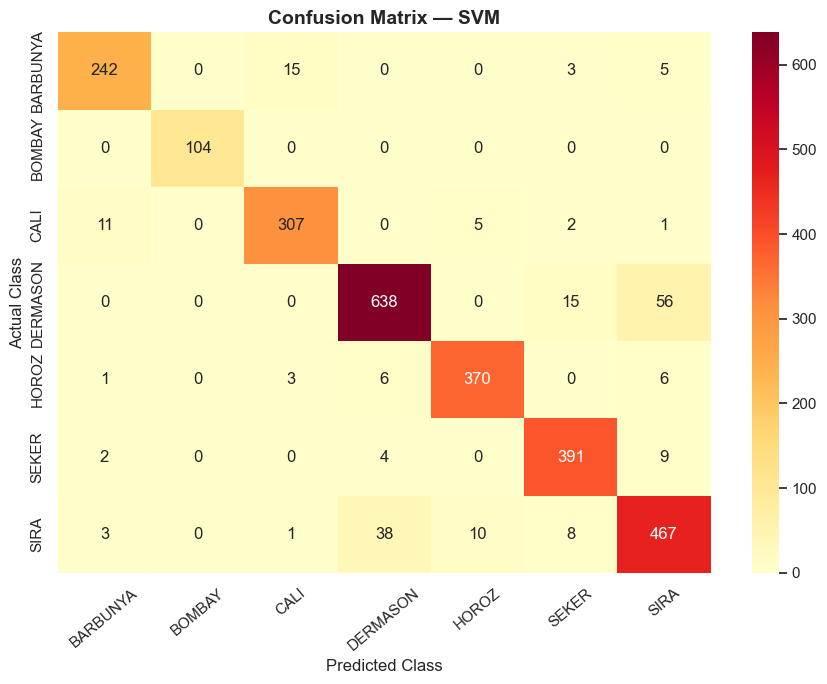


Final Classification Report — SVM:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.93      0.90      0.91       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.93      0.96      0.95       406
        SIRA       0.86      0.89      0.87       527

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



In [46]:
# Determine the best model name (without '(Tuned)' suffix handling)
best_model_name = best_row['Model']
best_model = all_final_models[best_model_name]

y_final_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_final_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

print(f'\nFinal Classification Report — {best_model_name}:')
print(classification_report(y_test, y_final_pred, target_names=le.classes_))

In [47]:
import joblib
joblib.dump(best_model, 'best_dry_bean_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']